# Regression and Trend Analysis Using StatsModels


## Introduction to Regression

Regression analysis is a statistical method used to model the relationship between a dependent variable (target) and one or more independent variables (predictors). It helps in understanding how the dependent variable changes when any one of the independent variables is varied, while the other independent variables are held fixed.

### Types of Regression Covered:
- **Linear Regression**:
    -  Models a linear relationship between variables.
    -  Linear Regression is one of the most fundamental and powerful statistical techniques used for modeling relationships between variables and making predictions.
    - Linear Regression models the relationship between:
        - Dependent Variable (Y) : Target / Output
        - Independent Variable (X) : Predictor / Input. 
        - It assumes a linear relationship between X and Y.


- **Multiple Linear Regression**: 
    - Multiple Linear Regression (MLR) extends simple linear regression by modeling the relationship between one dependent variable and two or more independent variables.
    - Extends linear regression to multiple predictors.
    - It models Dependent variable (Y) &  Multiple independent variables (X₁, X₂, X₃, …).



- **Logistic Regression**:
    - Logistic Regression is a classification algorithm used when the dependent variable is categorical (usually binary).
    - Unlike Linear Regression, it predicts probability, not continuous values.
    - Used for binary classification problems.


## Linear Regression with StatsModels

### Explanation
Linear regression assumes a linear relationship: Y = β0 + β1*X + ε, where:
- Y: Dependent variable
- X: Independent variable
- β0: Intercept
- β1: Slope coefficient
- ε: Error term

StatsModels uses Ordinary Least Squares (OLS) to estimate parameters by minimizing the sum of squared residuals.OLS stands for Ordinary Least Squares, which is the most common method used to estimate the coefficients in linear regression.

### Steps:
1. Prepare data.
2. Add constant term for intercept.
3. Fit the model.
4. Interpret summary: Coefficients, R-squared, p-values, etc.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     968.9
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           1.31e-52
Time:                        21:32:02   Log-Likelihood:                -200.46
No. Observations:                 100   AIC:                             404.9
Df Residuals:                      98   BIC:                             410.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4302      0.341     15.944      0.0

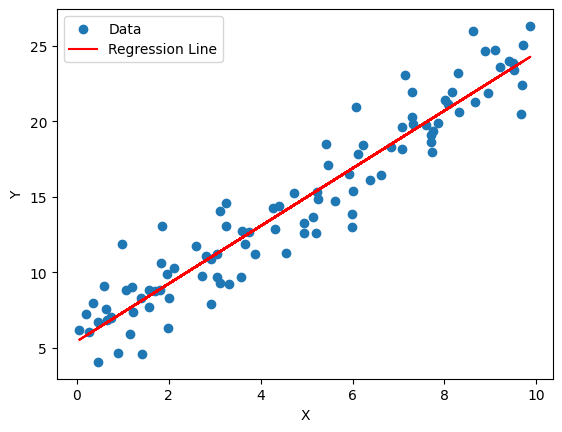

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Sample data
np.random.seed(42)
X = np.random.rand(100) * 10
Y = 2 * X + 5 + np.random.randn(100) * 2  # Linear relationship with noise

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(Y, X_const).fit() 

# Print summary
print(model.summary())

# Plot data and regression line
plt.scatter(X, Y, label='Data')
plt.plot(X, model.predict(X_const), color='red', label='Regression Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

### Interpretation
- **R-squared**: Proportion of variance in Y explained by X (closer to 1 is better).
- **Coef**: β0 (const) and β1 (x1).
- **P>|t|**: P-value for significance (typically < 0.05 indicates significant predictor).

## Multiple Linear Regression

### Explanation
Extends linear regression to multiple predictors: Y = β0 + β1*X1 + β2*X2 + ... + βn*Xn + ε.


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     328.3
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           2.55e-50
Time:                        21:32:03   Log-Likelihood:                -306.06
No. Observations:                 100   AIC:                             620.1
Df Residuals:                      96   BIC:                             630.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.5821      1.712     -1.509      0.1

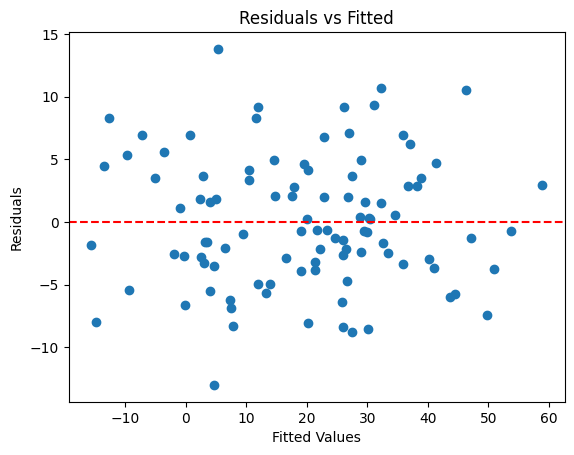

In [3]:
# Sample data
data = pd.DataFrame({
    'X1': np.random.rand(100) * 10,
    'X2': np.random.rand(100) * 20,
    'X3': np.random.rand(100) * 30
})
data['Y'] = 3 * data['X1'] + 2 * data['X2'] - 1 * data['X3'] + np.random.randn(100) * 5

# Predictors and constant
X_multi = data[['X1', 'X2', 'X3']]
X_multi_const = sm.add_constant(X_multi)
Y_multi = data['Y']

# Fit model
model_multi = sm.OLS(Y_multi, X_multi_const).fit()

# Summary
print(model_multi.summary())

# Residual plot
residuals = model_multi.resid
plt.scatter(model_multi.fittedvalues, residuals)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.axhline(0, color='red', linestyle='--')
plt.show()

## Logistic Regression

If we use linear regression then output can be less than 0 or greater than 1 but probabilities must be between 0 and 1. So we use Sigmoid function.
Models probability using logit function: logit(p) = β0 + β1*X + ...
p = 1 / (1 + exp(-logit(p)))

StatsModels uses maximum likelihood estimation.

Optimization terminated successfully.
         Current function value: 0.282132
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                  0.5929
Time:                        21:32:03   Log-Likelihood:                -28.213
converged:                       True   LL-Null:                       -69.295
Covariance Type:            nonrobust   LLR p-value:                 1.253e-19
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.0694      1.012     -5.010      0.000      -7.052      -3.086
x1             1.0750      0.

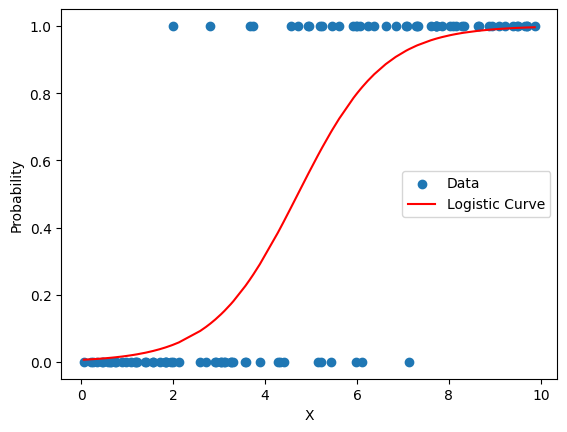

In [4]:
# Sample binary data
np.random.seed(42)
X_log = np.random.rand(100) * 10
prob = 1 / (1 + np.exp(-( -5 + X_log )))
Y_log = (np.random.rand(100) < prob).astype(int)

# Add constant for intercept because statsmodels does not add it by default
# In logistic regression constant is added so that the model can learn the baseline log-odds when all predictors are zero.
X_log_const = sm.add_constant(X_log)

# Fit logistic model  
model_log = sm.Logit(Y_log, X_log_const).fit()

# Summary
print(model_log.summary())

# Predict probabilities
preds = model_log.predict(X_log_const)
plt.scatter(X_log, Y_log, label='Data')
plt.plot(np.sort(X_log), np.sort(preds), color='red', label='Logistic Curve')
plt.xlabel('X')
plt.ylabel('Probability')
plt.legend()
plt.show()

## Trend Analysis

Trend analysis involves identifying patterns or trends in data over time. In the context of regression, we can use linear regression to fit a trend line to time series data to detect upward, downward, or stable trends.

It is commonly applied in:
   - Economics (stock prices, GDP)
   - Business (sales forecasting)
   - Social sciences (population growth)
   - Engineering (sensor data trends)

A trend is the general direction in which a dataset is moving over time:
- Upward trend: data increases over time
- Downward trend: data decreases over time
- No trend: data fluctuates around a constant mean

**Time Series Data**: Data points collected or recorded at specific time intervals.

**Detrending**: Removing the trend component from time series data.

**Seasonal Decomposition**: Breaking down time series into trend, seasonal, and residual components using StatsModels.

## Trend Analysis with StatsModels


For time series, we can fit a linear trend using regression on time index.
Use `seasonal_decompose` for decomposition.

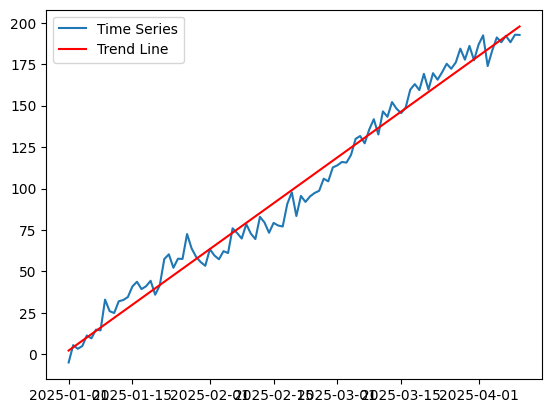

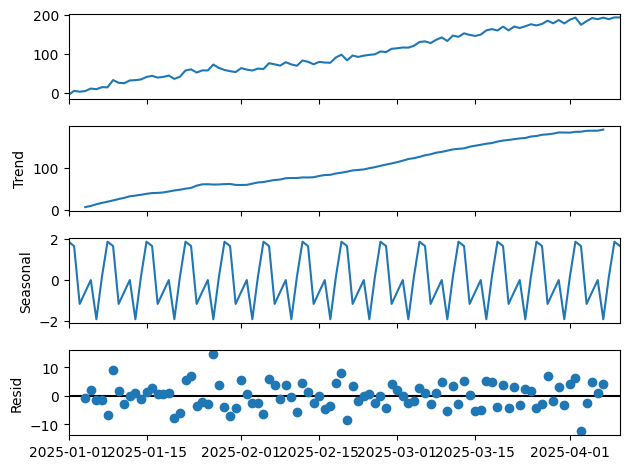

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Sample time series data
dates = pd.date_range(start='2025-01-01', periods=100, freq='D')
ts_data = pd.Series(2 * np.arange(100) + np.sin(np.arange(100)/10)*10 + np.random.randn(100)*5, index=dates)

# Trend via linear regression
time = np.arange(len(ts_data))
X_time = sm.add_constant(time)
model_trend = sm.OLS(ts_data, X_time).fit()
trend_line = model_trend.predict(X_time)

# Plot
plt.plot(ts_data, label='Time Series')
plt.plot(ts_data.index, trend_line, color='red', label='Trend Line')
plt.legend()
plt.show()

# Seasonal decomposition (assuming daily data with weekly seasonality)
decomp = seasonal_decompose(ts_data, model='additive', period=7)
fig = decomp.plot()
plt.show()

### Interpretation
- **Trend**: Long-term progression.
- **Seasonal**: Repeating patterns.
- **Residual**: Random noise.

